In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('최종_홍수취약성_랭킹.csv')

print("1. 반지하 주택(S1)과 하수도 인프라(S2, S3) 사이의 상관관계")
corr_s2, p_s2 = stats.pearsonr(df['S1_정규화'], df['S2_Vulnerability'])
corr_s3, p_s3 = stats.pearsonr(df['S1_정규화'], df['S3_Vulnerability'])

print(f"반지하(S1) vs 하수관거(S2) 상관계수: {corr_s2:+.4f} (P-value: {p_s2:.4f})")
print(f"반지하(S1) vs 빗물받이(S3) 상관계수: {corr_s3:+.4f} (P-value: {p_s3:.4f})")

print("반지하 주택(S1)과 사회적 약자계층(S4, S5) 사이의 상관관계")
corr_s4, p_s4 = stats.pearsonr(df['S1_정규화'], df['S4_Vulnerability'])
corr_s5, p_s5 = stats.pearsonr(df['S1_정규화'], df['S5_Vulnerability'])

print(f"반지하(S1) vs S4 상관계수: {corr_s4:+.4f} (P-value: {p_s4:.4f})")
print(f"반지하(S1) vs S5 상관계수: {corr_s5:+.4f} (P-value: {p_s5:.4f})")

1. 반지하 주택(S1)과 하수도 인프라(S2, S3) 사이의 상관관계
반지하(S1) vs 하수관거(S2) 상관계수: +0.1468 (P-value: 0.4839)
반지하(S1) vs 빗물받이(S3) 상관계수: -0.0991 (P-value: 0.6373)
반지하 주택(S1)과 사회적 약자계층(S4, S5) 사이의 상관관계
반지하(S1) vs S4 상관계수: +0.2154 (P-value: 0.3012)
반지하(S1) vs S5 상관계수: +0.2764 (P-value: 0.1811)


- 두 인프라 모두 P-value가 0.05를 초과하여 유의미한 상관관계가 없다.
이는 취약 거주지(반지하)에 배수 인프라가 집중되지 않고 흩어져 있는 미스매치 상태를 보여준다.
- 반지하 주택, 사회적 약자계층도 상관 X

-> 이 부분은 활용 X

In [9]:
print("2. 펌프장/저류조(AC)의 방어 효과 (독립표본 T-검정)")

# AC 지수 중앙값을 기준으로 두 그룹 분리
median_ac = df['AC_최종지수'].median()
high_ac_group = df[df['AC_최종지수'] >= median_ac]['V_최종지수']
low_ac_group  = df[df['AC_최종지수'] < median_ac]['V_최종지수']

# 두 집단 간 평균 차이 검정
t_stat_ac, p_val_ac = stats.ttest_ind(high_ac_group, low_ac_group)

print(f"펌프장/저류조 우수 그룹의 평균 홍수 취약성: {high_ac_group.mean():.4f}")
print(f"펌프장/저류조 미흡 그룹의 평균 홍수 취약성: {low_ac_group.mean():.4f}")
print(f"T-통계량: {t_stat_ac:.4f} (P-value: {p_val_ac:.4f})")

2. 펌프장/저류조(AC)의 방어 효과 (독립표본 T-검정)
펌프장/저류조 우수 그룹의 평균 홍수 취약성: 0.4122
펌프장/저류조 미흡 그룹의 평균 홍수 취약성: 0.6620
T-통계량: -3.4622 (P-value: 0.0021)


빗물 펌프장과 저류조 용량 확보는 피해를 막는 방어 효과를 가지고 있다.

In [10]:
print("3. 홍수 방재 정책의 핵심 타겟 도출 (OLS 다중회귀분석)")

# 독립변수(X)와 종속변수(Y) 설정
X = df[['표면유출_위험지수', 'S1_정규화', 'S2_Vulnerability', 'S3_Vulnerability', 'S4_Vulnerability', 'S5_Vulnerability','AC_최종지수']]
X = sm.add_constant(X) # 회귀식의 상수항(절편) 추가
Y = df['V_최종지수']

# statsmodels의 OLS(최소제곱법) 모델 적합
model = sm.OLS(Y, X).fit()

# 전체 통계표 출력 (R-squared, F-statistic, 변수별 P-value 등을 한눈에 확인)
print(model.summary())

3. 홍수 방재 정책의 핵심 타겟 도출 (OLS 다중회귀분석)
                            OLS Regression Results                            
Dep. Variable:                 V_최종지수   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     225.5
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           1.69e-15
Time:                        10:29:38   Log-Likelihood:                 59.935
No. Observations:                  25   AIC:                            -103.9
Df Residuals:                      17   BIC:                            -94.12
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const

In [11]:
# 회귀분석 조건 만족 검증
print("다중공선성 (VIF) 검증")

vifs = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'변수명': X.columns, 'VIF': vifs})

print(vif_df[1:].to_string(index=False)) 

다중공선성 (VIF) 검증
             변수명      VIF
       표면유출_위험지수 1.134761
          S1_정규화 1.335143
S2_Vulnerability 2.350252
S3_Vulnerability 1.880405
S4_Vulnerability 3.307248
S5_Vulnerability 3.199603
         AC_최종지수 1.640997


모든 VIF가 10 미만이므로 다중공선성 문제 없음.

In [12]:
print("잔차의 정규성 및 등분산성 검증")
residuals = model.resid

# 정규성 검정 (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)

# 등분산성 검정 (Breusch-Pagan)
bp_test = sms.het_breuschpagan(residuals, model.model.exog)
bp_p = bp_test[1]

print(f"정규성 (Shapiro-Wilk): P-value = {shapiro_p:.4f}")
print(f"등분산성 (Breusch-Pagan): P-value = {bp_p:.4f}")


잔차의 정규성 및 등분산성 검증
정규성 (Shapiro-Wilk): P-value = 0.2294
등분산성 (Breusch-Pagan): P-value = 0.6553


정규성과 등분산성 검증 모두 P-value가 0.05보다 크므로 귀무가설을 채택한다. 즉, 오차가 정규성과 등분산성을 가지고 있다.

In [13]:
print("이상치 탐지")
influence = model.get_influence()
cooks_d, _ = influence.cooks_distance

# 임계값 설정 (4 / 데이터 개수)
n = len(Y)
threshold = 4 / n
print(f"Cook's Distance 임계값: {threshold:.4f}")

# 이상치 추출
outlier_indices = np.where(cooks_d > threshold)[0]
outliers = df.loc[outlier_indices, ['자치구']]

if len(outliers) > 0:
    print(f"회귀선에 큰 영향을 미치는 이상치 의심 자치구: {len(outliers)}곳")
    print(outliers.to_string(index=False))
else:
    print("임계값을 초과하는 이상치 없음")

이상치 탐지
Cook's Distance 임계값: 0.1600
회귀선에 큰 영향을 미치는 이상치 의심 자치구: 5곳
자치구
중랑구
강북구
광진구
서초구
성북구


[결론 및 시사점 요약]
1. 모델의 설명력(R-squared)이 98.9%로 매우 강력한 예측력을 가진다.
2. 표면유출 위험지수(Coefficient: 0.5226)가 취약성을 높이는 가장 큰 요인이다.
3. 방어 인프라 중 하수관거(S2)나 빗물받이(S3)보다, 펌프장/저류조(AC, Coefficient: -0.9378)의 취약성 감소 효과가 압도적으로 뛰어남이 입증되었다.
4. 결론적으로 향후 방재 예산은 '표면유출 억제' 및 '저류/펌프 시설 확충'에 집중되어야 한다.

++ 모델은 VIF, 정규성 모두 만족하지만, Cook's distance 기준 5개 지역(중랑, 강북, 광진, 서초, 성북)이 이상치로 탐지되었다.

[이상치 포함 근거]
1. 현실 특수성 반영
- 서초구(분지형 지형) 등 해당 지역의 실제 지리직 특수성을 보여줄 수 있음.
- 즉, 인위적으로 제거 시 현실을 왜곡할 가능성 존재
2. 정책적 사각지대
- 일반적인 펌프/하수도 확충만으로는 수해를 막을 수 없는 곳을 의미
- 즉, 이상치에 해당하는 자치구는 맞춤형 특수 방재 정책이 필요하다는 증거
3. 객관성 입증
- 극단값을 삭제하지 않았음에도 모델의 설명력이 매우 높게 나타남


In [14]:
# [한글 폰트 설정]
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [15]:
# 1. 모델 재적합
X_vars = ['표면유출_위험지수', 'S1_정규화', 'S2_Vulnerability', 'S3_Vulnerability', 'S4_Vulnerability', 'S5_Vulnerability', 'AC_최종지수']
X = sm.add_constant(df[X_vars])
Y = df['V_최종지수']

model = sm.OLS(Y, X).fit()

In [16]:
# 2. 잔차(Residual) 
df['예측_취약성'] = model.predict(X)
df['잔차'] = df['V_최종지수'] - df['예측_취약성']

In [ ]:
# 3. 이상치 5개 구 필터링
outlier_names = ['중랑구', '강북구', '광진구', '서초구', '성북구']
outliers_df = df[df['자치구'].isin(outlier_names)].copy()

In [18]:
print("5개 이상치 지역의 잔차(예측 오차) 방향성 분석")
for idx, row in outliers_df.iterrows():
    name = row['자치구']
    actual = row['V_최종지수']
    pred = row['예측_취약성']
    res = row['잔차']
    
    direction = "과소 예측(실제 취약성이 더 높음)" if res > 0 else "과대 예측(실제 취약성이 더 낮음)"
    
    print(f"{name}: 실제({actual:.3f}) vs 예측({pred:.3f}) | 오차: {res:+.3f} -> {direction}")

5개 이상치 지역의 잔차(예측 오차) 방향성 분석
중랑구: 실제(0.819) vs 예측(0.769) | 오차: +0.050 -> 과소 예측(실제 취약성이 더 높음)
강북구: 실제(0.605) vs 예측(0.631) | 오차: -0.026 -> 과대 예측(실제 취약성이 더 낮음)
광진구: 실제(0.459) vs 예측(0.499) | 오차: -0.040 -> 과대 예측(실제 취약성이 더 낮음)
서초구: 실제(0.228) vs 예측(0.178) | 오차: +0.050 -> 과소 예측(실제 취약성이 더 높음)
성북구: 실제(0.000) vs 예측(-0.021) | 오차: +0.021 -> 과소 예측(실제 취약성이 더 높음)


- 양수(+) 잔차: 모델이 인프라만 보고 안전할 것이라 예측했으나, 실제론 훨씬 취약함. (지형적 악조건 의심)
- 음수(-) 잔차: 모델이 '위험할 것'이라 예측했으나, 실제론 방어를 잘함. (통계에 안 잡히는 특수 방어기제 의심)

서울시 평균 vs 이상치 5개 구 극단치 프로파일링 (시각화)


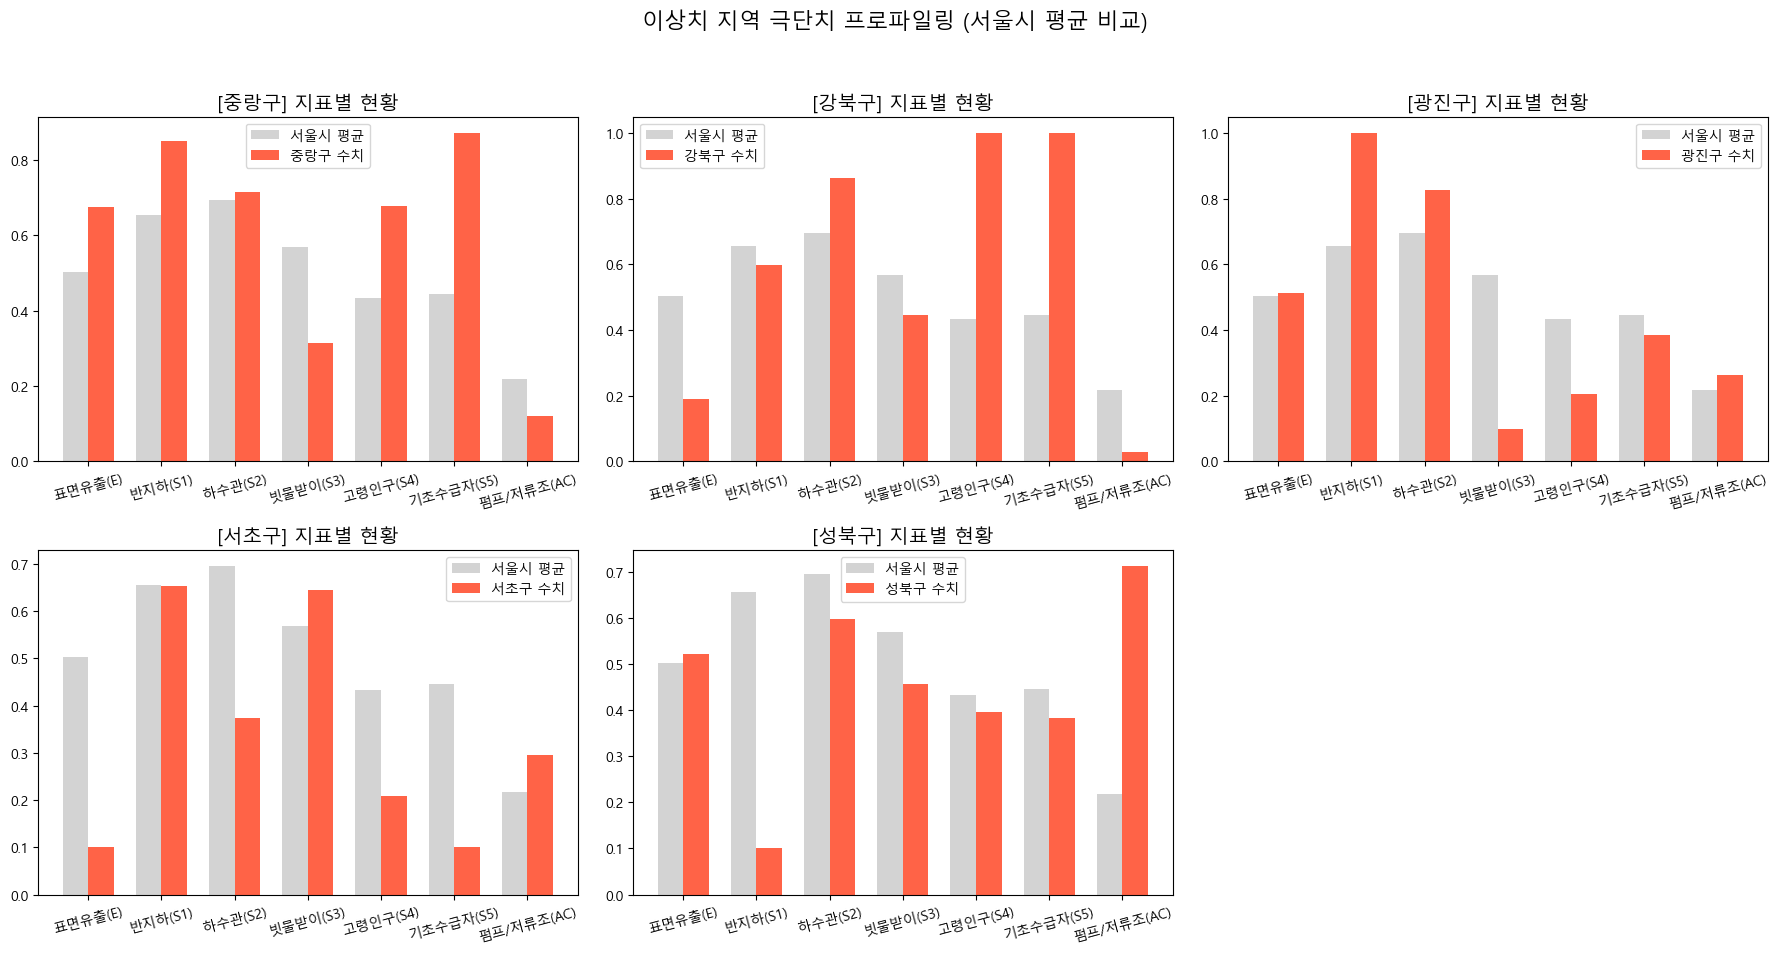

In [19]:
print("서울시 평균 vs 이상치 5개 구 극단치 프로파일링 (시각화)")
# 서울시 전체 평균 계산
seoul_mean = df[X_vars].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('이상치 지역 극단치 프로파일링 (서울시 평균 비교)', fontsize=16)

axes = axes.flatten()

for i, name in enumerate(outlier_names):
    ax = axes[i]
    district_data = df[df['자치구'] == name][X_vars].iloc[0]
    
    x = np.arange(len(X_vars))
    width = 0.35
    
    ax.bar(x - width/2, seoul_mean, width, label='서울시 평균', color='lightgray')
    ax.bar(x + width/2, district_data, width, label=f'{name} 수치', color='tomato')
    
    ax.set_title(f'[{name}] 지표별 현황', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(['표면유출(E)', '반지하(S1)', '하수관(S2)', '빗물받이(S3)', '고령인구(S4)', '기초수급자(S5)', '펌프/저류조(AC)'], rotation=15)
    ax.legend()


fig.delaxes(axes[5])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- E, S1, S2, S3, S4, S5는 1에 가까울수록 취약함을 나타냄.
- AC는 낮을수록 취약함을 나타냄.

### 1. 중랑구 : 사회적 취약계층 밀집과 하천 지형
- 데이터 분석
    - 모델 예측치(0.769)보다 실제 취약성(0.819)이 더 높은 과소 예측(+) 지역
    - 사회적 약자 지표(S4, S5) 비율이 높게 반영되면서 통계적으로 매우 위험한 지역으로 분류

- 스토리텔링
    - 거대한 중랑천을 끼고 있어 근본적인 범람 위험을 안고 있는 지형적 특성에 더해, 수해 발생 시 대피가 곤란하거나 피해가 큰 사회적 취약계층(고령자 및 기초수급자)이 다수 밀집해 있음
    - 물리적인 인프라가 한계에 다다랐을 때, 취약계층의 늦은 대피 속도와 복구 능력이 결합하여 실제 체감되는 홍수 취약성과 재산/인명 피해 규모가 통계적 수치 이상으로 증폭된 것으로 볼 수 있음

- 정책 제언
    - 단순한 토목 공사 중심의 하드웨어적 방재를 넘어, '소프트웨어적 방재 시스템' 도입이 최우선으로 시급함
    - 침수 발생 시 고령자 및 거동 불편자를 전담하여 대피시키는 1:1 맞춤형 재난 복지 네트워크 구축 및 취약계층 거주 반지하 주택의 차수판 우선 설치 의무화


### 2. 강북구 : 통계적 취약성을 상쇄하는 고지대
- 데이터 분석
    - 모델 예측치(0.631)보다 실제 취약성(0.605)이 더 낮게 나타난 과대 예측(-) 지역
    - 사회적 취약 계층 비율이 높아 모델은 이 지역을 위험할 것으로 예측함
- 스토리텔링
    - 사회적 약자가 다수 거주하고 인프라가 좋지않아 통계상으로는 침수에 치명적일 것 같지만, 실제로는 빗물이 고이지 않고 흘러내려 가는 북한산 자락 '고지대'라는 지형적 특성이 방패 역할을 함
    - 데이터와 인구 통계에는 잡히지 않는 '자연 지형의 배수 능력'이 물리적, 사회적 취약성을 압도하여 빗물 피해를 줄여준 특수 케이스
- 정책 제언
    - 대규모 지하 저류조 같은 대형 방재 인프라 신설보다 현재의 지형적 이점을 유지하는 방향이 예산 대비 효율적
    - 경사지에서 빠른 속도로 쏟아지는 표면유출수가 저지대로 단번에 휩쓸려 내려가지 않도록 빗물받이의 촘촘한 정비와 산사태 방지 옹벽 등 핀포인트 형태의 국소적 관리가 요구됨

### 3. 광진구 : 보이지 않는 방어기제가 작동하는 강변의 안전지대
- 데이터 분석
    - 예측 취약성(0.499)보다 실제 취약성(0.459)이 더 낮게 나타난 과대 예측(-) 지역
    - 5개 이상치 구 중 강북구 다음으로 예측 대비 실제 방어력이 뛰어남
- 스토리텔링
    - 남쪽으로 한강을 넓게 맞대고 있어 범람 위험이 클 것으로 직관적으로 예상되나, 인구학적 지표(S4, S5)나 일반 배수 인프라 통계만으로는 설명되지 않는 방어기제가 작동 중인 것으로 추측
    - 뚝섬유원지 등 거대한 수변 공간이 자연 저류지 역할을 하거나 한강변의 견고한 제방 시스템이 통계 외적인 방어력을 제공하고 있는 것으로 해석 가능
- 정책 제언
    - 현재 구축된 거시적인 홍수 방어 시스템과 한강변의 수자원 통제 인프라가 꽤 훌륭하게 작동하고 있음을 시사함.
    - 새로운 대형 예산 투입보다는 기존 펌프장 네트워크의 가동률 유지와 하수관거 준설 작업 등 현재의 방어력을 온전히 보존하기 위한 선제적 유지보수에 집중

### 4.서초구 : 인프라를 무력화시키는 항아리 지형
- 데이터 분석
    - 모델 예측치(0.178)보다 실제 취약성(0.228)이 더 높은 과소 예측(+) 지역.
    - S4, S5 비율이 타 자치구 대비 매우 낮고 기본 인프라(E, S1, S2, S3)가 양호해 모델은 안전하다고 예측
    - 그러나 핵심 방어막인 AC 지수가 0.296으로 하위권에 머물러 있음

- 스토리텔링
    - 취약계층 비율이 적고 부유한 동네라는 사회적 통계, 양호한 배수관망 등 모델이 선호하는 모든 안전 지표를 갖췄음에도, 강남역 일대의 항아리형 저지대라는 공간적 특수성이 모든 장점을 흡수해버림
    - 다른 곳에서 흘러들어온 물이 순식간에 집중되지만, 이를 감당할 저류 용량(2,203㎥)과 펌프 시설이 유입량을 버텨내지 못해 통계적 예측치를 깨고 침수가 발생

- 정책 제언
    - 서초구에는 단순히 하수관을 넓히는 선형적 방재가 통하지 않음
    - 저지대로 쏟아지는 물을 강제로 모아 배출할 수 있는 대심도 빗물 배수터널 수준의 거대한 입체적 인프라 신설이 필요
    - 대심도 빗물 배수터널 : 도시의 극심한 침수 피해를 막기위해 지하 40-50M 깊이에 건설되는 거대한 지하 저류 터널

### 5. 성북구 : 높은 저류 용량이 만들어낸 안전지대
- 데이터 분석
    - 실제 취약성 0.000(가장 안전함), 모델 예측치마저 -0.021로 한계선을 뚫고 내려간 지역
    - 하수관(S2)과 빗물받이(S3) 취약성이 중간 수준(0.4~0.5) 존재함에도, 방어력인 AC 지수가 0.711로 1위

- 스토리텔링
    - 고령자와 기초수급자(S4, S5)가 다수 거주하고 있어 사회적 민감도가 높음에도 불구하고, 다중회귀분석에서 증명된 "AC(펌프장/저류조)가 가장 강력한 방어 무기"라는 가설을 현실에서 완벽하게 증명해냄.
    - 펌프장 개수는 2개뿐이지만, 저류 용량이 무려 12,194㎥에 달함
    - 하수관망이 다소 취약해도, 거대한 저류조로 인해 완벽한 방어력을 보여줌.

- 정책 제언
    - 홍수 방어 인프라 배치의 모범 자치구
    - 대규모 저류 시설의 효과가 확실하게 입증된 만큼, 현재 시설의 주기적인 내부 준설 및 스마트 수위 모니터링 시스템 구축 등에 예산을 집중하여 완벽한 방어력을 영구적으로 유지해야 함